In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 모델 경로와 테스트 데이터 경로 설정
MODEL_PATH = r"C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\best_phishing_model.pth"
TEST_DATA_PATH = r"C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\1차모델_테스트데이터셋.csv"

In [ ]:
# 사용자 정의 Dataset 클래스 (필요에 따라 수정)
class PhishingDataset(Dataset):
    def __init__(self, dataframe, feature_columns, label_column):
        self.features = dataframe[feature_columns].values.astype(np.float32)
        self.labels = dataframe[label_column].values.astype(np.long)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return torch.tensor(self.features[idx]), torch.tensor(self.labels[idx])

In [ ]:
# 기본 신경망 모델 클래스 (실제 모델 구조에 맞게 수정 필요)
class PhishingModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_classes=2):
        super(PhishingModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_size, hidden_size//2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(hidden_size//2, num_classes)
    
    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        x = self.fc3(x)
        return x

In [ ]:
def load_model_and_data():
    """모델과 데이터를 로드하는 함수"""
    try:
        # 테스트 데이터 로드
        test_df = pd.read_csv(TEST_DATA_PATH, encoding='utf-8')
        print(f"테스트 데이터 로드 완료: {test_df.shape}")
        print(f"컬럼: {list(test_df.columns)}")
        
        # 모델 상태 로드
        checkpoint = torch.load(MODEL_PATH, map_location='cpu')
        print("모델 체크포인트 로드 완료")
        
        return test_df, checkpoint
    
    except Exception as e:
        print(f"데이터 또는 모델 로드 중 오류 발생: {e}")
        return None, None

In [ ]:
def prepare_data(test_df):
    """데이터 전처리 및 준비"""
    # 레이블 컬럼 찾기 (일반적인 이름들)
    possible_label_cols = ['label', 'target', 'phishing', 'is_phishing', 'class', 'y']
    label_col = None
    
    for col in possible_label_cols:
        if col in test_df.columns:
            label_col = col
            break
    
    if label_col is None:
        print("가능한 레이블 컬럼들:", possible_label_cols)
        print("실제 컬럼들:", list(test_df.columns))
        label_col = input("레이블 컬럼명을 입력하세요: ")
    
    # 피처 컬럼들 (레이블 컬럼 제외)
    feature_cols = [col for col in test_df.columns if col != label_col]
    
    print(f"레이블 컬럼: {label_col}")
    print(f"피처 컬럼 수: {len(feature_cols)}")
    
    return feature_cols, label_col

In [ ]:
def evaluate_model(model, test_loader, device):
    """모델 평가 및 성능 지표 계산"""
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for features, labels in test_loader:
            features, labels = features.to(device), labels.to(device)
            
            outputs = model(features)
            probabilities = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    return np.array(all_predictions), np.array(all_labels), np.array(all_probabilities)

In [ ]:
def calculate_metrics(y_true, y_pred, y_prob=None):
    """성능 지표 계산"""
    # 기본 지표들
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    # 클래스별 지표
    precision_per_class = precision_score(y_true, y_pred, average=None)
    recall_per_class = recall_score(y_true, y_pred, average=None)
    f1_per_class = f1_score(y_true, y_pred, average=None)
    
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class
    }
    
    return metrics

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names=['정상', '피싱']):
    """혼동 행렬 시각화"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('실제 값')
    plt.xlabel('예측 값')
    plt.show()
    
    return cm

In [ ]:
def prepare_data(test_df):
    """데이터 전처리 및 준비"""
    # 레이블 컬럼 찾기 (일반적인 이름들)
    possible_label_cols = ['label', 'target', 'phishing', 'is_phishing', 'class', 'y']
    label_col = None
    
    for col in possible_label_cols:
        if col in test_df.columns:
            label_col = col
            break
    
    if label_col is None:
        print("가능한 레이블 컬럼들:", possible_label_cols)
        print("실제 컬럼들:", list(test_df.columns))
        label_col = input("레이블 컬럼명을 입력하세요: ")
    
    # 피처 컬럼들 (레이블 컬럼 제외)
    feature_cols = [col for col in test_df.columns if col != label_col]
    
    print(f"레이블 컬럼: {label_col}")
    print(f"피처 컬럼 수: {len(feature_cols)}")
    
    return feature_cols, label_col

In [ ]:
def evaluate_model(model, test_loader, device):
    """모델 평가 및 성능 지표 계산"""
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for features, labels in test_loader:
            features, labels = features.to(device), labels.to(device)
            
            outputs = model(features)
            probabilities = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    return np.array(all_predictions), np.array(all_labels), np.array(all_probabilities)

In [ ]:
def calculate_metrics(y_true, y_pred, y_prob=None):
    """성능 지표 계산"""
    # 기본 지표들
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    # 클래스별 지표
    precision_per_class = precision_score(y_true, y_pred, average=None)
    recall_per_class = recall_score(y_true, y_pred, average=None)
    f1_per_class = f1_score(y_true, y_pred, average=None)
    
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class
    }
    
    return metrics

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names=['정상', '피싱']):
    """혼동 행렬 시각화"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('실제 값')
    plt.xlabel('예측 값')
    plt.show()
    
    return cm

In [ ]:
def main():
    """메인 실행 함수"""
    print("=== 딥러닝 모델 성능 평가 시작 ===")
    
    # 데이터와 모델 로드
    test_df, checkpoint = load_model_and_data()
    if test_df is None or checkpoint is None:
        return
    
    # 데이터 준비
    feature_cols, label_col = prepare_data(test_df)
    
    # 데이터셋 생성
    test_dataset = PhishingDataset(test_df, feature_cols, label_col)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # 모델 초기화 및 가중치 로드
    input_size = len(feature_cols)
    model = PhishingModel(input_size)
    
    # 체크포인트에서 모델 상태 로드 (키 확인 필요)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    
    # 디바이스 설정
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    print(f"사용 디바이스: {device}")
    print(f"모델 입력 크기: {input_size}")
    
    # 모델 평가
    print("\n=== 모델 평가 중... ===")
    y_pred, y_true, y_prob = evaluate_model(model, test_loader, device)
    
    # 성능 지표 계산
    metrics = calculate_metrics(y_true, y_pred, y_prob)
    
    # 결과 출력
    print("\n=== 성능 평가 결과 ===")
    print(f"정확도 (Accuracy): {metrics['accuracy']:.4f}")
    print(f"정밀도 (Precision): {metrics['precision']:.4f}")
    print(f"재현율 (Recall): {metrics['recall']:.4f}")
    print(f"F1 점수: {metrics['f1_score']:.4f}")
    
    print("\n=== 클래스별 성능 ===")
    class_names = ['정상', '피싱']
    for i, class_name in enumerate(class_names):
        if i < len(metrics['precision_per_class']):
            print(f"{class_name} 클래스:")
            print(f"  정밀도: {metrics['precision_per_class'][i]:.4f}")
            print(f"  재현율: {metrics['recall_per_class'][i]:.4f}")
            print(f"  F1 점수: {metrics['f1_per_class'][i]:.4f}")
    
    # 상세 분류 보고서
    print("\n=== 상세 분류 보고서 ===")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # 혼동 행렬 출력 및 시각화
    print("\n=== 혼동 행렬 ===")
    cm = plot_confusion_matrix(y_true, y_pred, class_names)
    print(cm)
    
    # 결과를 CSV 파일로 저장
    results_df = pd.DataFrame({
        'actual': y_true,
        'predicted': y_pred,
        'probability_class_0': y_prob[:, 0] if y_prob.shape[1] > 1 else 1 - y_prob.flatten(),
        'probability_class_1': y_prob[:, 1] if y_prob.shape[1] > 1 else y_prob.flatten()
    })
    
    output_path = "evaluation_results.csv"
    results_df.to_csv(output_path, index=False, encoding='utf-8')
    print(f"\n평가 결과가 '{output_path}' 파일로 저장되었습니다.")

if __name__ == "__main__":
    main()

c:\Users\user\Desktop\woogawooga\woogawooga_project\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== BERT 기반 피싱 탐지 모델 성능 평가 시작 ===
테스트 데이터 로드 완료: (1000, 3)
컬럼: ['file_name', 'text', 'is_phishing']
모델 체크포인트 로드 완료
BERT 모델용 텍스트 데이터 전처리 시작...
원본 데이터 shape: (1000, 3)
컬럼들: ['file_name', 'text', 'is_phishing']

텍스트 컬럼: text
레이블 컬럼: is_phishing
데이터 개수: 1000
레이블 분포: {1: 500, 0: 500}
KLUE BERT 토크나이저 로드 완료


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


KLUE BERT 모델 초기화 완료
모델 가중치 로드 중 오류: Error(s) in loading state_dict for BertForSequenceClassification:
	size mismatch for bert.embeddings.word_embeddings.weight: copying a param with shape torch.Size([8002, 768]) from checkpoint, the shape in current model is torch.Size([32000, 768]).
사전 훈련된 가중치로 진행합니다.
사용 디바이스: cpu
텍스트 데이터 개수: 1000

=== 모델 평가 중... ===

=== 성능 평가 결과 ===
정확도 (Accuracy): 0.4860
정밀도 (Precision): 0.4416
재현율 (Recall): 0.4860
F1 점수: 0.3654

=== 클래스별 성능 ===
정상 클래스:
  정밀도: 0.4925
  재현율: 0.9220
  F1 점수: 0.6421
피싱 클래스:
  정밀도: 0.3906
  재현율: 0.0500
  F1 점수: 0.0887

=== 상세 분류 보고서 ===
              precision    recall  f1-score   support

          정상       0.49      0.92      0.64       500
          피싱       0.39      0.05      0.09       500

    accuracy                           0.49      1000
   macro avg       0.44      0.49      0.37      1000
weighted avg       0.44      0.49      0.37      1000


=== 혼동 행렬 ===


c:\Users\user\Desktop\woogawooga\woogawooga_project\.venv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\user\Desktop\woogawooga\woogawooga_project\.venv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\user\Desktop\woogawooga\woogawooga_project\.venv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\user\Desktop\woogawooga\woogawooga_project\.venv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49905 (\N{HANGUL SYLLABLE SING}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\user\Desktop\woogawooga\woogawooga_project\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sa

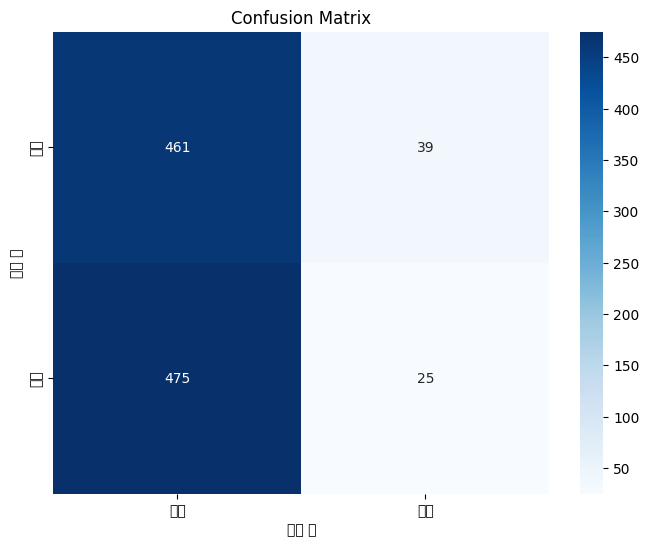

[[461  39]
 [475  25]]

평가 결과가 'bert_evaluation_results.csv' 파일로 저장되었습니다.


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertForSequenceClassification

# 모델 경로와 테스트 데이터 경로 설정
MODEL_PATH = r"C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\best_phishing_model.pth"
TEST_DATA_PATH = r"C:\Users\user\Desktop\woogawooga\woogawooga_project\dataset\1차모델_테스트데이터셋.csv"

# BERT 기반 텍스트 분류 Dataset 클래스
class PhishingTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # 토큰화
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# BERT 기반 모델 클래스 (실제 모델과 호환)
class PhishingBertModel(nn.Module):
    def __init__(self, model_name='klue/bert-base', num_classes=2):
        super(PhishingBertModel, self).__init__()
        self.bert = BertForSequenceClassification.from_pretrained(
            model_name, 
            num_labels=num_classes
        )
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits

def load_model_and_data():
    """모델과 데이터를 로드하는 함수"""
    try:
        # 테스트 데이터 로드
        test_df = pd.read_csv(TEST_DATA_PATH, encoding='utf-8')
        print(f"테스트 데이터 로드 완료: {test_df.shape}")
        print(f"컬럼: {list(test_df.columns)}")
        
        # 모델 상태 로드
        checkpoint = torch.load(MODEL_PATH, map_location='cpu')
        print("모델 체크포인트 로드 완료")
        
        return test_df, checkpoint
    
    except Exception as e:
        print(f"데이터 또는 모델 로드 중 오류 발생: {e}")
        return None, None

def prepare_data(test_df):
    """BERT 모델용 텍스트 데이터 준비"""
    print("BERT 모델용 텍스트 데이터 전처리 시작...")
    print(f"원본 데이터 shape: {test_df.shape}")
    print(f"컬럼들: {list(test_df.columns)}")
    
    # 레이블 컬럼 찾기
    possible_label_cols = ['label', 'target', 'phishing', 'is_phishing', 'class', 'y']
    label_col = None
    
    for col in possible_label_cols:
        if col in test_df.columns:
            label_col = col
            break
    
    if label_col is None:
        print("\n가능한 레이블 컬럼들:", possible_label_cols)
        print("실제 컬럼들:", list(test_df.columns))
        label_col = input("레이블 컬럼명을 입력하세요: ")
    
    # 텍스트 컬럼 찾기
    text_col = 'text'
    if text_col not in test_df.columns:
        print(f"'{text_col}' 컬럼을 찾을 수 없습니다.")
        text_cols = [col for col in test_df.columns if col != label_col and test_df[col].dtype == 'object']
        if text_cols:
            text_col = text_cols[0]
            print(f"대신 '{text_col}' 컬럼을 텍스트로 사용합니다.")
        else:
            raise ValueError("텍스트 컬럼을 찾을 수 없습니다!")
    
    # 텍스트와 레이블 추출
    texts = test_df[text_col].tolist()
    labels = test_df[label_col].tolist()
    
    print(f"\n텍스트 컬럼: {text_col}")
    print(f"레이블 컬럼: {label_col}")
    print(f"데이터 개수: {len(texts)}")
    print(f"레이블 분포: {pd.Series(labels).value_counts().to_dict()}")
    
    return texts, labels, text_col, label_col

def evaluate_model(model, test_loader, device):
    """BERT 모델 평가"""
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids, attention_mask)
            logits = outputs.logits  # SequenceClassifierOutput에서 logits 추출
            probabilities = torch.softmax(logits, dim=1)
            _, predicted = torch.max(logits, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    return np.array(all_predictions), np.array(all_labels), np.array(all_probabilities)

def calculate_metrics(y_true, y_pred, y_prob=None):
    """성능 지표 계산"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    precision_per_class = precision_score(y_true, y_pred, average=None)
    recall_per_class = recall_score(y_true, y_pred, average=None)
    f1_per_class = f1_score(y_true, y_pred, average=None)
    
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class
    }
    
    return metrics

def plot_confusion_matrix(y_true, y_pred, class_names=['정상', '피싱']):
    """혼동 행렬 시각화"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('실제 값')
    plt.xlabel('예측 값')
    plt.show()
    
    return cm

def main():
    """메인 실행 함수"""
    print("=== BERT 기반 피싱 탐지 모델 성능 평가 시작 ===")
    
    # 데이터와 모델 로드
    test_df, checkpoint = load_model_and_data()
    if test_df is None or checkpoint is None:
        return
    
    # 텍스트 데이터 준비
    texts, labels, text_col, label_col = prepare_data(test_df)
    
    # BERT 토크나이저 초기화
    try:
        tokenizer = BertTokenizer.from_pretrained('klue/bert-base')
        print("KLUE BERT 토크나이저 로드 완료")
    except:
        tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
        print("다국어 BERT 토크나이저 로드 완료")
    
    # 데이터셋 생성
    test_dataset = PhishingTextDataset(texts, labels, tokenizer, max_length=512)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)  # 배치 크기 줄임
    
    # 모델 초기화
    try:
        model = BertForSequenceClassification.from_pretrained('klue/bert-base', num_labels=2)
        print("KLUE BERT 모델 초기화 완료")
    except:
        model = BertForSequenceClassification.from_pretrained('bert-base-multilingual-cased', num_labels=2)
        print("다국어 BERT 모델 초기화 완료")
    
    # 체크포인트에서 모델 상태 로드
    try:
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'], strict=False)
        else:
            model.load_state_dict(checkpoint, strict=False)
        print("모델 가중치 로드 완료")
    except Exception as e:
        print(f"모델 가중치 로드 중 오류: {e}")
        print("사전 훈련된 가중치로 진행합니다.")
    
    # 디바이스 설정
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    print(f"사용 디바이스: {device}")
    print(f"텍스트 데이터 개수: {len(texts)}")
    
    # 모델 평가
    print("\n=== 모델 평가 중... ===")
    y_pred, y_true, y_prob = evaluate_model(model, test_loader, device)
    
    # 성능 지표 계산
    metrics = calculate_metrics(y_true, y_pred, y_prob)
    
    # 결과 출력
    print("\n=== 성능 평가 결과 ===")
    print(f"정확도 (Accuracy): {metrics['accuracy']:.4f}")
    print(f"정밀도 (Precision): {metrics['precision']:.4f}")
    print(f"재현율 (Recall): {metrics['recall']:.4f}")
    print(f"F1 점수: {metrics['f1_score']:.4f}")
    
    print("\n=== 클래스별 성능 ===")
    class_names = ['정상', '피싱']
    for i, class_name in enumerate(class_names):
        if i < len(metrics['precision_per_class']):
            print(f"{class_name} 클래스:")
            print(f"  정밀도: {metrics['precision_per_class'][i]:.4f}")
            print(f"  재현율: {metrics['recall_per_class'][i]:.4f}")
            print(f"  F1 점수: {metrics['f1_per_class'][i]:.4f}")
    
    # 상세 분류 보고서
    print("\n=== 상세 분류 보고서 ===")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # 혼동 행렬 출력 및 시각화
    print("\n=== 혼동 행렬 ===")
    cm = plot_confusion_matrix(y_true, y_pred, class_names)
    print(cm)
    
    # 결과를 CSV 파일로 저장
    results_df = pd.DataFrame({
        'text': texts,
        'actual': y_true,
        'predicted': y_pred,
        'probability_class_0': y_prob[:, 0] if y_prob.shape[1] > 1 else 1 - y_prob.flatten(),
        'probability_class_1': y_prob[:, 1] if y_prob.shape[1] > 1 else y_prob.flatten()
    })
    
    output_path = "bert_evaluation_results.csv"
    results_df.to_csv(output_path, index=False, encoding='utf-8')
    print(f"\n평가 결과가 '{output_path}' 파일로 저장되었습니다.")

if __name__ == "__main__":
    main()